In [1]:
!pip install numpy pandas seaborn scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Dataset: https://www.kaggle.com/datasets/aminizahra/pima-indians-diabetes

The dataset contains the following features:
1. Number of Pregnancies: Number of times pregnant.

2. Glucose: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.

3. Blood Pressure: Diastolic blood pressure (mm Hg).

4. Skin Thickness: Triceps skin fold thickness (mm).

5. Insulin: 2-Hour serum insulin (mu U/ml).

6. BMI: Body mass index (weight in kg/(height in m)^2).

7. Diabetes Pedigree Function: A function that scores likelihood of diabetes based on family history.

8. Age: Age in years.

9. Outcome: Class variable (0 if non-diabetic, 1 if diabetic).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("pima-indians-diabetes.csv")
print("--- İlk 5 Satır ---")
display(df.head())
print("\n\n--- Genel Bilgiler ve Eksik Değer Kontrolü ---")
df.info()
print("\n\n--- İstatistiksel Özet ---")
display(df.describe())
print("\n\n--- Etiket Dağılımı (Outcome) ---")
print(df['Outcome'].value_counts(normalize=True))

--- İlk 5 Satır ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetespedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1




--- Genel Bilgiler ve Eksik Değer Kontrolü ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetespedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


--- İstatistiksel Özet ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetespedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000




--- Etiket Dağılımı (Outcome) ---
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


Hedef değişken (Outcome) dağılımının dengesiz olması sebebiyle, özelliklerin dağılımına ve model eğitim parametrelerine özel olarak müdahale edilecektir. Veri setindeki BMI, Insulin, SkinThickness, BloodPressure ve Glucose gibi tıbbi değişkenlerde biyolojik olarak imkansız olan 0 değerlerinin yer aldığı gözlemlenmiştir. Bu hatalı değerlerin sisteme olumsuz etkisini engellemek adına; bu sütunlardaki sıfırlar Outcome (hedef sınıf) değişkenine göre gruplanacak ve her sınıfın kendi içindeki medyan değerleri ile doldurularak model performansları optimize edilecektir.

,Glucose,BloodPressure,SkinThickness,Insulin,BMI
count,768.000000,768.000000,768.000000,768.000000,768.000000
mean,121.677083,72.389323,29.089844,141.753906,32.434635
std,30.464161,12.106039,8.890820,89.100847,6.880498
min,44.000000,24.000000,7.000000,14.000000,18.200000
25%,99.750000,64.000000,25.000000,102.500000,27.500000
50%,117.000000,72.000000,28.000000,102.500000,32.050000
75%,140.250000,80.000000,32.000000,169.500000,36.600000
max,199.000000,122.000000,99.000000,846.000000,67.100000


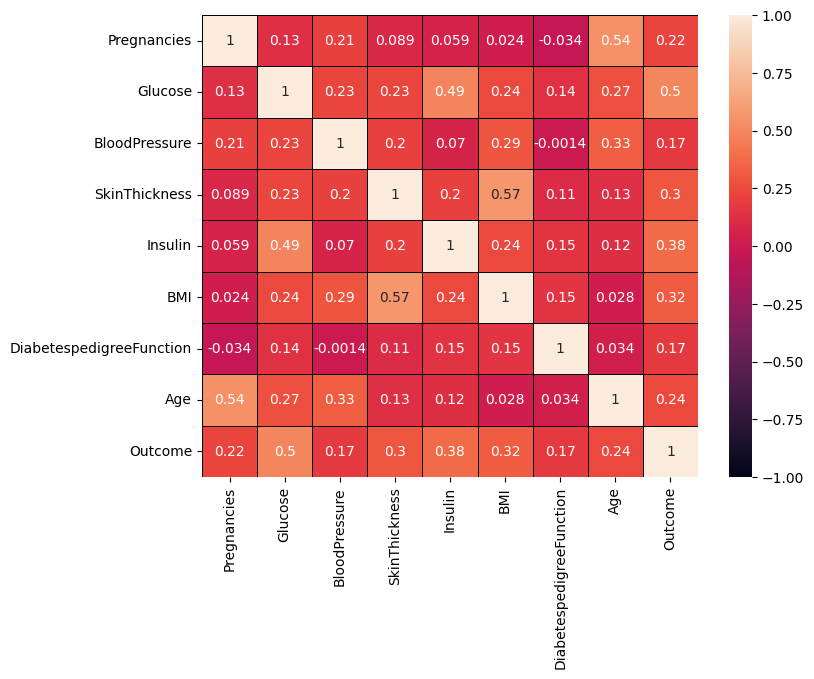

In [5]:
df_clean = df.copy()
invalid_zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in invalid_zero_cols:
    df_clean[col] = df_clean[col].replace(0, np.nan)

for col in invalid_zero_cols:
    df_clean[col] = df_clean.groupby("Outcome")[col].transform(lambda x: x.fillna(x.median()))

display(df_clean[invalid_zero_cols].describe())
plt.figure(figsize=(8,6))
sns.heatmap(df_clean.corr(),annot=True, vmin=-1, vmax=1,linewidths=0.5, linecolor="black")
plt.show()

In [6]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [7]:
X=df_clean.drop(columns=["Outcome"])
y=df_clean["Outcome"]
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [8]:
models={
    "Decision Tree Classifier":DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "Support Vector Classifier":SVC(kernel='rbf', random_state=42, class_weight="balanced"),
    "Gradient Boosting Classifier":GradientBoostingClassifier(random_state=42),
    "Random Forest Classifier":RandomForestClassifier(random_state=42, class_weight="balanced",n_estimators=100),
    "K-Nearest neighbors Classifier": KNeighborsClassifier(n_neighbors=5)
}

In [11]:
results_list = []
for name, model in models.items():
    if name in ["Random Forest Classifier", "Gradient Boosting Classifier", "Decision Tree Classifier"]:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        train_acc = model.score(X_train, y_train)
        test_acc = model.score(X_test, y_test)
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        train_acc = model.score(X_train_scaled, y_train)
        test_acc = model.score(X_test_scaled, y_test)
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    cm = confusion_matrix(y_test, y_pred)
    cr = classification_report(y_test, y_pred)
    
    results_list.append({
        "Model Name": name,
        "Train Accuracy": round(train_acc, 4),
        "Test Accuracy": round(test_acc, 4),
        "5-Fold CV Mean": round(cv_scores.mean(), 4)
    })

In [12]:
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)
display(results_df)

,Model Name,Train Accuracy,Test Accuracy,5-Fold CV Mean
0,Gradient Boosting Classifier,0.9837,0.8831,0.8696
1,Random Forest Classifier,1.0000,0.8571,0.8713
2,Decision Tree Classifier,1.0000,0.8506,0.8143
3,Support Vector Classifier,0.8909,0.8442,0.8338
4,K-Nearest neighbors Classifier,0.8762,0.8117,0.8046


Base parametrelerle yapılan ilk eğitim sonuçları incelendiğinde, en yüksek test doğruluğunu (%88.31) ve Cross-Validation skorunu (%88.54) Gradient Boosting Classifier modelinin verdiği görülmektedir. Ancak modelin eğitim doğruluğu (%98.37) ile test doğruluğu arasında yaklaşık %10'luk bir makas farkı bulunmaktadır. Benzer şekilde Random Forest ve Decision Tree modelleri de eğitim setinde %100 başarı göstererek veriyi tamamen ezberlemiştir (overfitting).

Modelin gerçek hayattaki yeni ve görmediği veriler karşısında daha tutarlı, kararlı ve gerçekçi tahminler yapabilmesini sağlamak adına bu aşırı öğrenme (ezberleme) durumunun kontrol altına alınması gerekmektedir.

Gradient Boosting modelinin detaylarda kaybolmasını engellemek amacıyla; ağaç derinliğini sınırlayacak (max_depth), yapraklardaki minimum örnek sayısını artıracak (min_samples_leaf) ve her adımda verinin alt kümelerini rastgele seçecek (subsample) parametreler üzerinde GridSearchCV yöntemi uygulanacaktır. Bu sayede eğitim-test skoru arasındaki makas daraltılacak ve model daha genelleyici bir yapıya kavuşturulacaktır.

In [14]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4],                        
    'min_samples_leaf': [3, 5, 7],               
    'subsample': [0.7, 0.8, 0.9]                
}

gb_base = GradientBoostingClassifier(random_state=42)
grid_search = GridSearchCV(estimator=gb_base, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid_search.fit(X_train, y_train)
best_gb_model = grid_search.best_estimator_
tuned_train_acc = best_gb_model.score(X_train, y_train)
tuned_test_acc = best_gb_model.score(X_test, y_test)
tuned_cv_score = cross_val_score(best_gb_model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1).mean()

print("--- Yeni Ayarlanmış Gradient Boosting Sonuçları ---")
print(f"En İyi Parametreler: {grid_search.best_params_}")
print(f"Train Accuracy: {tuned_train_acc:.4f}")
print(f"Test Accuracy : {tuned_test_acc:.4f}")
print(f"5-Fold CV Mean: {tuned_cv_score:.4f}")
print(f"Yeni Train-Test Farkı: %{((tuned_train_acc - tuned_test_acc) * 100):.2f}")

--- Yeni Ayarlanmış Gradient Boosting Sonuçları ---
En İyi Parametreler: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 7, 'n_estimators': 50, 'subsample': 0.9}
Train Accuracy: 0.9593
Test Accuracy : 0.8831
5-Fold CV Mean: 0.8909
Yeni Train-Test Farkı: %7.62


In [13]:
import pickle
import os
os.makedirs('../models', exist_ok=True)
final_tuned_model = grid_search.best_estimator_
with open('../models/diabetes_model.pkl', 'wb') as f:
    pickle.dump(final_tuned_model, f)